In the name of God
### Question 4


##### 4-1 Intro
In the following notebook we are going to develop an autoencoder, to reduce the dimension of our dataset, and then use the encoder part with simple dense MLP network to classify the data.
The dataset used is the MNIST dataset which can be accessed using TensorFlow (tf.keras.datasets.mnist) but since I already had the file I used that
 

##### 4-2 Loading the dataset and preprocessing

__Loading the dataset__

In [1]:
import numpy as np
import tensorflow as tf

with np.load("mnist.npz") as data:
    x_train, y_train = data["x_train"], data["y_train"]
    x_test, y_test = data["x_test"], data["y_test"]

print(f"x_train.shape = {x_train.shape}")
print(f"x_train.shape = {y_train.shape}")

2025-03-20 16:45:05.740825: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-20 16:45:05.777211: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742476505.818932   73292 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742476505.831065   73292 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742476505.860903   73292 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

x_train.shape = (60000, 28, 28)
x_train.shape = (60000,)


__Flattening the data__ since each data is a 28*28 matrix, in order to use it in our network we shall flatten it to a 784-dimensional vector 

In [2]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print(f"x_train.shape = {x_train.shape}")
print(f"x_test.shape = {x_test.shape}")

x_train[32].max()

x_train.shape = (60000, 784)
x_test.shape = (10000, 784)


np.uint8(255)

__Normalising the data__ in order to avoid bias in our network due to the size of the input, we need to normalise the data in the [0, 1] range

In [3]:
x_train = x_train.astype("float64") / 255.0
x_test = x_test.astype("float64") / 255.0

x_test[32].max()

np.float64(0.996078431372549)

#### 4-3 Designing and Implementing the models

##### 4-3-1 Designing and Training the auto encoders
For this section we are going to implement two autoencoders, each representing a latent space with a different size.

**Model One:** Autoencoder with 8 output neurons in the encoder  
  - **Architecture** (the number of neurons and activation function in each layer):  
    - Encoder: 784, 128 (ReLU), 8 (ReLU).  
    - Decoder: 8, 128 (ReLU), 784 (Linear).  
  - **Training Settings:**  
    - Loss Function: MSE.  
    - Number of Training Epochs: At least 20.  

**Model Two:**  
  - **Architecture:**  
    - Encoder: 784, 128 (ReLU), 4 (ReLU).  
    - Decoder: 4, 128 (ReLU), 784 (Linear).  
  - **Training Settings:** Similar to Model One.  

In order to simplify the code, a function has been defined to create the model based on the size of the latened space (This was possible due to the fact that both models had 3 layers for their encoder/decoder and only the size of the last/first layer was variable)

In [4]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

def build_autoencoder(latent_space_dimension):
    #Encoder
    encoder_input = Input(shape=(784,))
    middle_layer = Dense(
        128, 
        activation="relu"
    )(encoder_input)
    
    latent_output = Dense(
        latent_space_dimension, 
        activation="relu", 
        name="latent_layer"
    )(middle_layer)

    encoder = Model(
        encoder_input, 
        latent_output, 
        name="Encoder"
    )

    #Decoder
    decoder_input = Input(
        shape=(latent_space_dimension,)
    )
    
    middle_layer = Dense(
        128, 
        activation="relu"
    )(decoder_input)
    
    decoder_output = Dense(
        784, 
        activation="linear"
    )(middle_layer)

    decoder = Model(
        decoder_input, 
        decoder_output, 
        name="Decoder"
    )

    autoencoder_input = encoder_input
    autoencoder_output = decoder(latent_output)
    autoencoder = Model(autoencoder_input, autoencoder_output, name="Autoencoder")

    return encoder, decoder, autoencoder


Now that we can build the models, we call the functions, build our models and train them!

MSE has been chosen as the loss function and we employed adam as the optimizer

In [5]:
(encoder_latent_space_8,
 decoder_latent_space_8,
 autoencoder_latent_space_8) = build_autoencoder(
    latent_space_dimension=8
)
(encoder_latent_space_4,
 decoder_latent_space_4,
 autoencoder_latent_space_4) = build_autoencoder(
    latent_space_dimension=4
)

autoencoder_latent_space_8.compile(
    optimizer="adam", 
    loss="mse"
)
autoencoder_latent_space_4.compile(
    optimizer="adam", 
    loss="mse"
)

autoencoder_latent_space_8_history = autoencoder_latent_space_8.fit(
    x_train, 
    x_train, 
    epochs=40, 
    batch_size=32, 
    validation_data=(x_test, x_test)
)
autoencoder_latent_space_4_history = autoencoder_latent_space_4.fit(
    x_train, 
    x_train, 
    epochs=40, 
    batch_size=32, 
    validation_data=(x_test, x_test)
)

2025-03-20 16:45:11.112538: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-03-20 16:45:11.112573: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-03-20 16:45:11.112580: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: smani24-ROG-Zephyrus-G16-GU603VV-GU603VV
2025-03-20 16:45:11.112585: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] hostname: smani24-ROG-Zephyrus-G16-GU603VV-GU603VV
2025-03-20 16:45:11.112724: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:197] libcuda reported version is: 550.120.0
2025-03-20 16:45:11.112744: I external/local_xla/xla/stream_executor/cuda/cu

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.0509 - val_loss: 0.0350
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0343 - val_loss: 0.0323
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0322 - val_loss: 0.0313
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0314 - val_loss: 0.0308
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0307 - val_loss: 0.0304
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0304 - val_loss: 0.0302
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0302 - val_loss: 0.0299
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0299 - val_loss: 0.0298
Epoch 9/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 0.0297 - val_loss: 0.0296
Epoch 10/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0295 - val_loss: 0.0295
Epoch 11/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0294 - val_loss: 0.0293
Epoch 12/40
1875/18

We then proceed to plot the loss function for both of these models (on both the training and validation/Test sets)

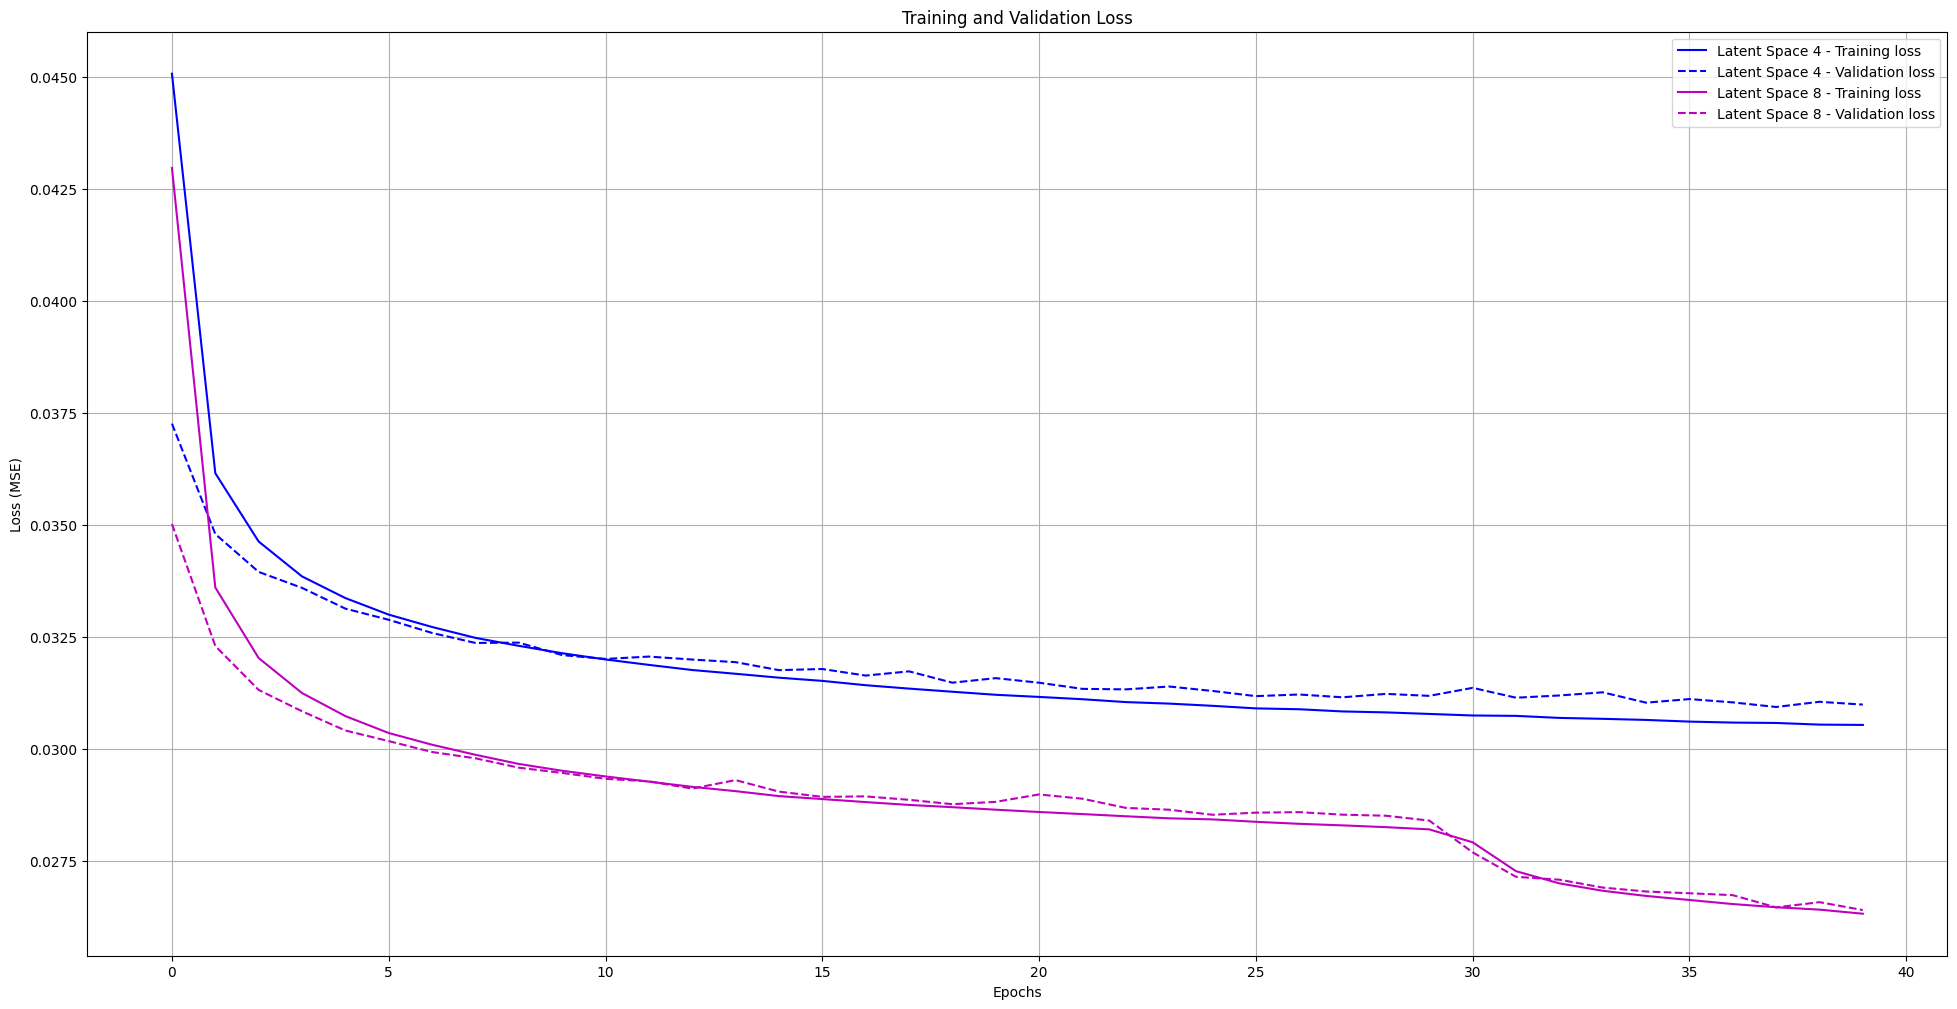

In [7]:
import matplotlib.pyplot as plt

def plot_auto_encoder_history():
    plt.figure(figsize=(24, 12))
    plt.title("Training and Validation Loss")
    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")

    colors = ['b', 'g', 'r', 'k', 'm']
    def plot_training_history(history, label, name, color_number):
        plt.plot(
            history.history[name], 
            label=f"{label} - Training {name}",
            linestyle="-",
            color=colors[color_number]
        )
        plt.plot(
            history.history[f"val_{name}"], 
            label=f"{label} - Validation {name}",
            linestyle="--",
            color=colors[color_number]
        )

    plot_training_history(
        history=autoencoder_latent_space_4_history, 
        label="Latent Space 4",
        name="loss",
        color_number=0
    )
    plot_training_history(
        history=autoencoder_latent_space_8_history, 
        label="Latent Space 8",
        name="loss",
        color_number=4
    )

    plt.legend()
    plt.show()

plot_auto_encoder_history()

As we can see, the latent space of size 8 preforms better than 4, this could show that maybe in order to represent the data with higher accuracy, we might need more than 4 neurons at the latent space.
We can also see that maybe if we let the network to train a while longer the performance might have been better, but due to hardware limitation it was not possible

##### 4-3-2 Implementing the MLP for classification

After training our autoencoders, we are now going to train a simple MLP with with one hidden layer (4 Neurons) to preform classification.

Since we have multiple classes (numbers 0 to 9) we need to first encode them with one-hot encoding, this has been done with the to_categorical() functions

In [8]:
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Input

y_train_onehot = to_categorical(
    y_train, 
    num_classes=10
)
y_test_onehot = to_categorical(
    y_test, 
    num_classes=10
)

def build_classifier(
    encoder, 
    latent_dimension, 
    extra_layer=True
):
    encoder.trainable = False

    input_layer = Input(shape=(784,))
    
    latent_output = encoder(input_layer)

    first_hidden_layer = Dense(
        latent_dimension,
        activation="relu"
    )(latent_output)

    middle_layer = Dense(
        4,
        activation="relu"
    )(first_hidden_layer)

    if extra_layer:
        middle_layer = Dense(
            4, 
            activation="relu"
        )(middle_layer)

    output_layer = Dense(
        10, 
        activation="softmax"
    )(middle_layer)

    classifier = Model(
        input_layer, 
        output_layer
    )
    classifier.compile(
        loss="categorical_crossentropy", 
        optimizer="adam", 
        metrics=["accuracy"]
    )
    
    return classifier


Now we need to extract the encoding part of the auto encoder and call our function to create the deep belief network

In [9]:
classifier_8 = build_classifier(
    encoder_latent_space_8, 
    latent_dimension=8
)


classifier_4_extra_layer = build_classifier(
    encoder_latent_space_4, 
    latent_dimension=4
)
classifier_4 = build_classifier(
    encoder_latent_space_4,
    latent_dimension=4,
    extra_layer=False
)

classifier_8_history = classifier_8.fit(
    x_train, 
    y_train_onehot, 
    epochs=40, 
    batch_size=32, 
    validation_data=(x_test, y_test_onehot)
)
classifier_4_history = classifier_4.fit(
    x_train, 
    y_train_onehot, 
    epochs=40, 
    batch_size=32, 
    validation_data=(x_test, y_test_onehot)
)
classifier_4_extra_layer_history = classifier_4_extra_layer.fit(
    x_train, 
    y_train_onehot, 
    epochs=40, 
    batch_size=32, 
    validation_data=(x_test, y_test_onehot)
)

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.2945 - loss: 1.9145 - val_accuracy: 0.5144 - val_loss: 1.3070
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5208 - loss: 1.2538 - val_accuracy: 0.5518 - val_loss: 1.1386
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5529 - loss: 1.1381 - val_accuracy: 0.5852 - val_loss: 1.0707
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5805 - loss: 1.0666 - val_accuracy: 0.6009 - val_loss: 1.0278
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6053 - loss: 1.0246 - val_accuracy: 0.6048 - val_loss: 1.0080
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6212 - loss: 0.9980 - val_accuracy: 0.6396 - val_loss: 0.9729
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6426 - loss: 0.9699 - val_accuracy: 0.6582 - val_loss: 0.9486
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6703 - loss: 0.9343 -

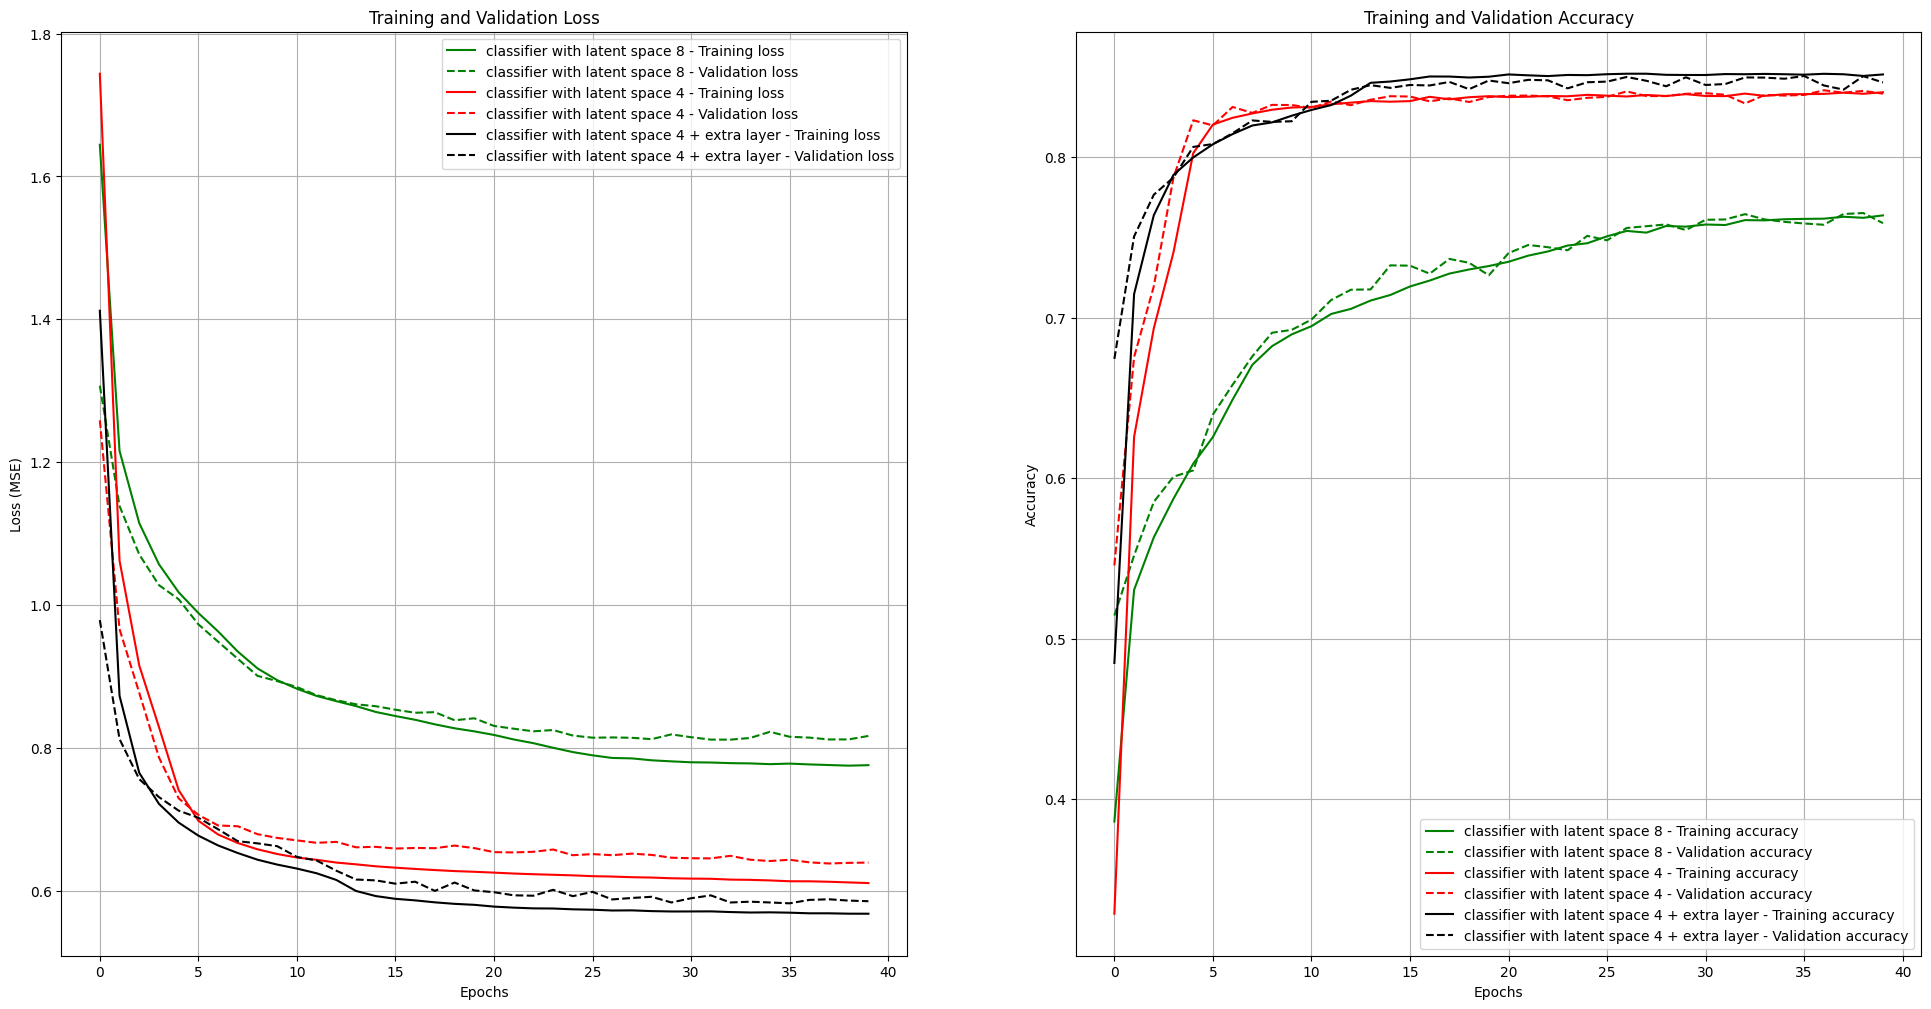

In [11]:
def plot_classifier_history():
    colors = ['b', 'g', 'r', 'k', 'm']
    def plot_training_history(history, label, name, color_number):
        plt.plot(
            history.history[name], 
            label=f"{label} - Training {name}",
            linestyle="-",
            color=colors[color_number]
        )
        plt.plot(
            history.history[f"val_{name}"], 
            label=f"{label} - Validation {name}",
            linestyle="--",
            color=colors[color_number]
        )

    plt.figure(figsize=(24, 12))
    plt.subplot(1, 2, 1)
    plt.title("Training and Validation Loss")
    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")



    plot_training_history(
        history=classifier_8_history, 
        label="classifier with latent space 8",
        name="loss",
        color_number=1
    )
    plot_training_history(
        history=classifier_4_history, 
        label="classifier with latent space 4",
        name="loss",
        color_number=2
    )
    plot_training_history(
        history=classifier_4_extra_layer_history, 
        label="classifier with latent space 4 + extra layer",
        name="loss",
        color_number=3
    )
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.title("Training and Validation Accuracy")
    plt.grid()
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")

    plot_training_history(
        history=classifier_8_history, 
        label="classifier with latent space 8",
        name="accuracy",
        color_number=1
    )
    plot_training_history(
        history=classifier_4_history, 
        label="classifier with latent space 4",
        name="accuracy",
        color_number=2
    )
    plot_training_history(
        history=classifier_4_extra_layer_history, 
        label="classifier with latent space 4 + extra layer",
        name="accuracy",
        color_number=3
    )

    plt.legend()
    plt.show()

plot_classifier_history()

As seen from the plots, the classifier network with 8 latent space preformed better that the normal classifier with the latent space of 4, but it was outperformed by the classifier with 4 dimension latent space that had an extra layer. This shows that even though some information was lost in the auto encoder with the latent space of 4, with an extra layer, it was able to outperform the 8 dimension one, this indicates that the Feed Forward section of the 8-dimensional one was not optimal and had room for more improvement (maybe by changing the architecture)

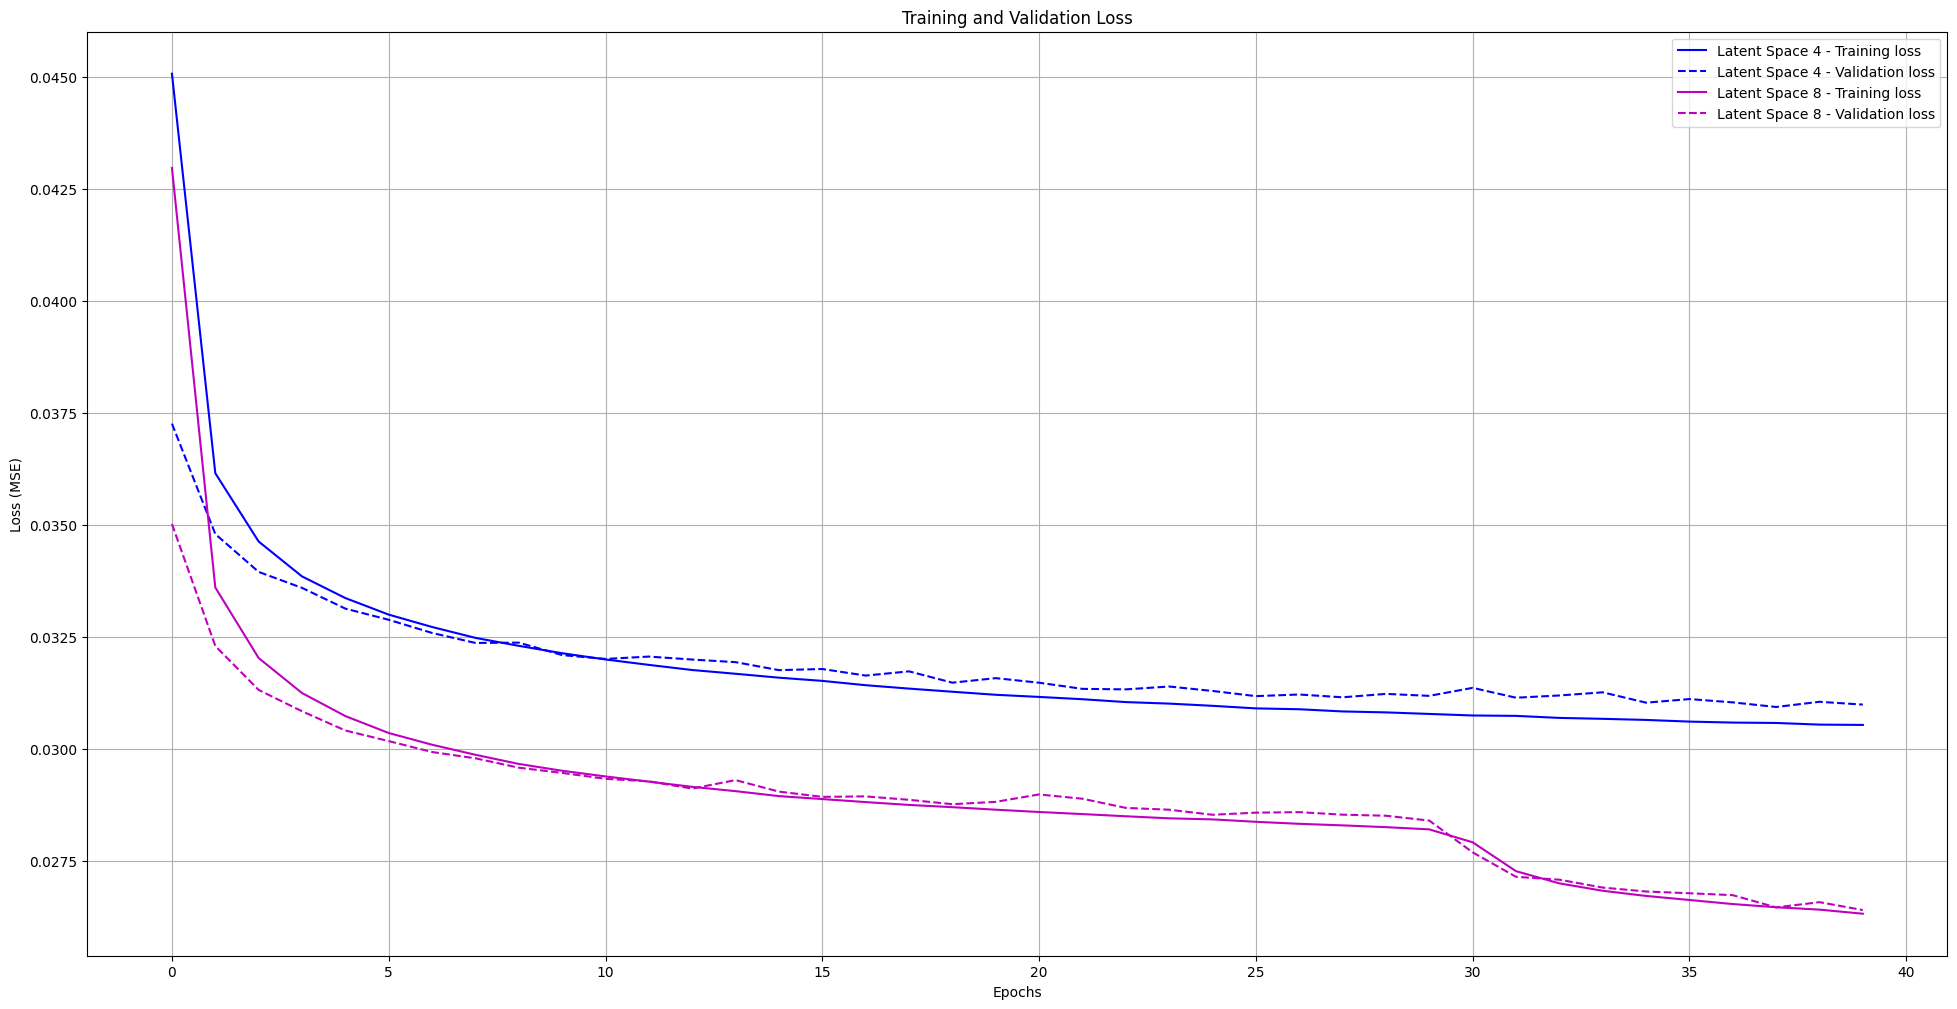

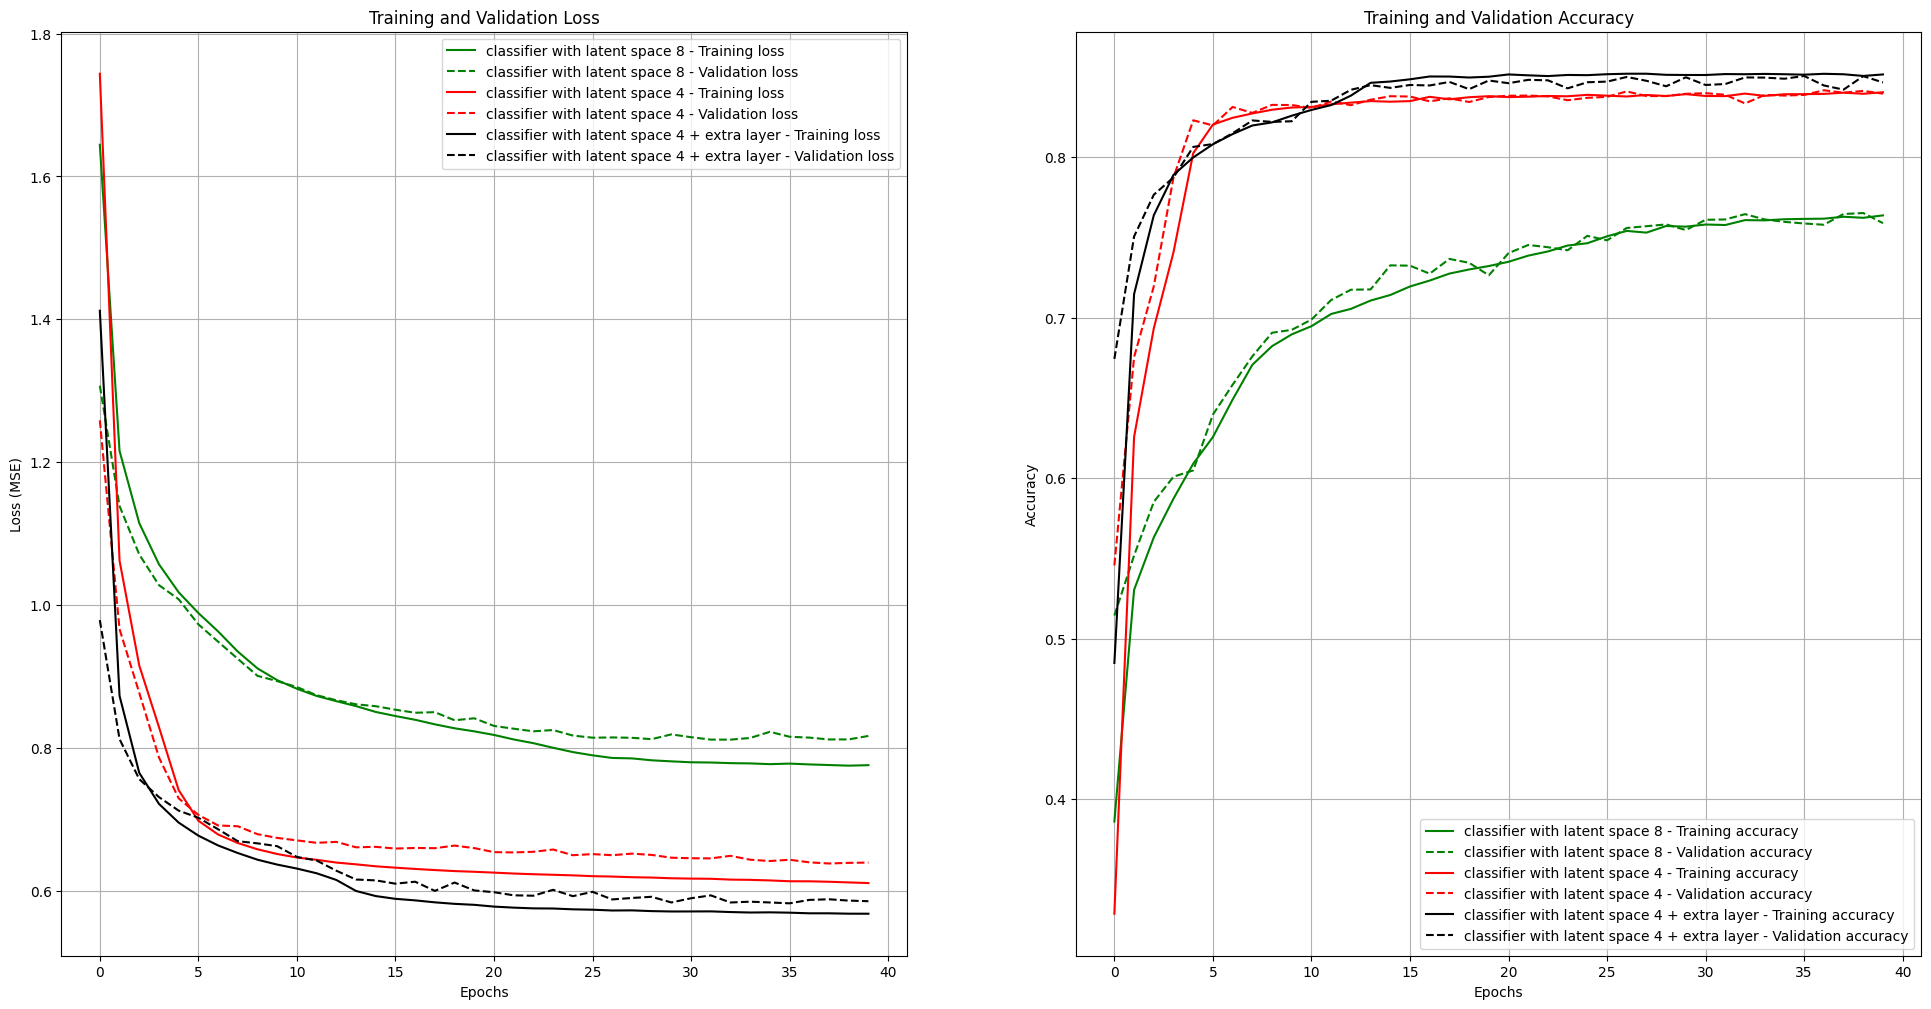

In [12]:
plot_auto_encoder_history()
plot_classifier_history()